# 03 · Reinforcement Learning — DDPG + PPO

**Vai trò notebook**: kiến trúc DDPG (paper Xiong et al replica) + PPO backup, training curves, sample decisions, lessons learned (DDPG saturated tanh → PPO khắc phục).

**Owner**: Duc
**Deadline**: 2026-05-22
**Slide chapter**: 4 — Implementation (Strategies → RL subsection)

## Mục tiêu
1. Kiến trúc actor-critic của DDPG (continuous action) + PPO (clipped objective)
2. Training log → curves (actor_loss, critic_loss, episode_return)
3. Sample forward pass: state → action
4. Failure analysis: DDPG saturated tanh (PRD §14 Risk #7) + bằng chứng

## Defense Q&A
- Q: DDPG khác PPO ở điểm gì? Tại sao PPO khắc phục được vấn đề DDPG?
- Q: Network architecture chi tiết (layers, hidden_dim, activation)?
- Q: State + action space định nghĩa thế nào?
- Q: Reward function?


## TODO-01: state-action-space — formalize MDP
- **OWNER**: Duc   **DEPENDS**: none
- **READ**: `src/trading_env.py:VNTradingEnv.observation_space`, `action_space`, `_reward`
- **WRITE**: markdown cells với spec MDP + code cell in ra space shapes
- **CONSTRAINTS**:
  Markdown sections:
  ```
  ### State (s_t)
  - Per-ticker (×5): price OHLCV window, RSI, MACD, Bollinger
  - Portfolio: current weights, cash ratio
  - Total dim: <X>
  ### Action (a_t)
  - Continuous target weights ∈ [-1, 1]^5
  - Long-only? Long-short?
  ### Reward (r_t)
  - r_t = log(value_t / value_{t-1}) - λ * turnover  (or similar)
  ### Discount γ
  - 0.99 (config)
  ```
- **VALIDATE**:
  ```python
  env = VNTradingEnv(...)
  print(env.observation_space.shape, env.action_space.shape)
  ```
- **DEFENSE Q&A**: "State / action / reward của bạn?" → đọc 3 sections này.

## **Part 1: Trading Environment Design:**

The project uses a custom Gymnasium-based trading environment (VNTradingEnv) to simulate realistic portfolio management in the Vietnamese stock market. The environment is specifically designed for reinforcement learning agents such as DDPG and PPO.

### **Action Space:**

The action space is defined as a continuous vector of portfolio target weights:

*Box(low=-1, high=1, shape=(5,))*

Each dimension corresponds to one VN30 ticker:

- VCB
- FPT
- HPG
- VIC
- VNM

The environment applies several realistic portfolio constraints:

- Negative weights are clipped to zero (long-only trading)
- Total portfolio allocation is normalized to at most 100%
- Remaining capital is held as cash

This formulation allows continuous portfolio optimization while remaining compatible with the Vietnamese equity market.

### **Observation Space:**

The observation vector has a fixed dimension of 56 and consists of:

- 45 normalized technical indicator features: 9 indicators for each of the 5 tickers: Includes RSI, MACD, SMA, Bollinger Bands, ATR, etc.
- 5 current portfolio weights: Represents current asset allocation
- 5 previous-day returns: Captures short-term market momentum
- 1 cash ratio: Fraction of total portfolio value held as cash

The final observation structure is:

45 indicators + 5 weights + 5 returns + 1 cash ratio = 56 features

### **Reward Function:**

The default reward function is the **logarithmic portfolio return**:

*reward = log(PV_t / PV_{t-1})*

where:

**PV_t** is the current portfolio value

**PV_t−1** is the previous portfolio value

***Log-return*** is widely used in quantitative finance because it:

- stabilizes training
- is additive over time
- naturally penalizes large drawdowns
- improves numerical stability for reinforcement learning

### **Vietnam Market Constraints:**

The environment incorporates several Vietnam-specific trading rules to improve realism:

- ±7% daily price band limit
- Lot-size constraint (100 shares)
- Asymmetric buy/sell transaction fees (0.15% for buy fee and 0.25% for sell fee cause of transfer tax)
- Optional T+2 settlement mechanism

These constraints ensure that the trained agents operate under realistic HOSE trading conditions.

### **Lookahead Bias Prevention:**

The environment strictly prevents lookahead bias. At trading session T, the agent only observes information available before or at session T.

Technical indicators are precomputed using historical windows only, and all environment transitions are designed to avoid future information leakage.

This is critical to ensure valid backtesting and reliable evaluation of reinforcement learning agents.

In [2]:
# TODO-01: print env spaces

from src.trading_env import VNTradingEnv
from src.env_data_loader import load_market_data
import numpy as np

# Load training market data
md = load_market_data('train')

# Create environment
env = VNTradingEnv(md)

# Print Gym spaces
print("=" * 60)
print("ENVIRONMENT SPACES")
print("=" * 60)

print("\nObservation Space:")
print(env.observation_space)
print("Shape:", env.observation_space.shape)
print("Dtype:", env.observation_space.dtype)

print("\nAction Space:")
print(env.action_space)
print("Shape:", env.action_space.shape)
print("Dtype:", env.action_space.dtype)
print("Action range:", env.action_space.low[0], "to", env.action_space.high[0])

# Reset environment
obs, info = env.reset(seed=42)

print("\n" + "=" * 60)
print("INITIAL OBSERVATION")
print("=" * 60)

print("Observation shape:", obs.shape)
print("Observation dtype:", obs.dtype)

print("\nFirst 10 observation values:")
print(np.round(obs[:10], 4))

print("\nEnvironment info:")
print(info)

print("\n" + "=" * 60)
print("DIMENSION BREAKDOWN")
print("=" * 60)

print(f"Technical indicators : {5 * 9}")
print(f"Portfolio weights    : {5}")
print(f"Previous returns     : {5}")
print(f"Cash ratio           : {1}")
print(f"Total observation dim: {obs.shape[0]}")

print("\nEnvironment initialized successfully.")

ENVIRONMENT SPACES

Observation Space:
Box(-inf, inf, (56,), float32)
Shape: (56,)
Dtype: float32

Action Space:
Box(-1.0, 1.0, (5,), float32)
Shape: (5,)
Dtype: float32
Action range: -1.0 to 1.0

INITIAL OBSERVATION
Observation shape: (56,)
Observation dtype: float32

First 10 observation values:
[-2.5783 -2.6395 -2.7327  0.87    1.266   1.5157  0.9217  1.5152  0.1617
  1.4586]

Environment info:
{'date': '2019-05-03T00:00:00', 't': 78, 'cash': 1000000000.0, 'holdings': [0, 0, 0, 0, 0], 'portfolio_value': 1000000000.0, 'close_t': [28.56999969482422, 15.8100004196167, 8.09000015258789, 49.9900016784668, 77.33000183105469]}

DIMENSION BREAKDOWN
Technical indicators : 45
Portfolio weights    : 5
Previous returns     : 5
Cash ratio           : 1
Total observation dim: 56

Environment initialized successfully.


### State (s_t)
Observation vector là **56-dim z-score chuẩn hóa**:
- **45 chỉ báo kỹ thuật** (9 chỉ báo × 5 ticker):  
  Per ticker: Price/Volume window, RSI, MACD, Bollinger Bands
- **5 trọng số hiện tại** (current portfolio weights × price):  
  Biểu diễn tỷ lệ vốn đầu tư trong mỗi ticker
- **5 lợi suất trước đó** (previous 1-day returns):  
  Momentum signal cho mỗi ticker
- **1 tỷ lệ tiền mặt** (cash/portfolio_value):  
  Phần vốn không được đầu tư

**Không có lookahead bias:** Toàn bộ data tại session T chỉ dùng các timestamps < T (CLAUDE.md §1).

### Action (a_t)
- **Loại:** Continuous box ∈ [-1, 1]^5 (DDPG, PPO)
- **Ý nghĩa:** Target **relative weights** (tối ưu hóa trước clamping)
- **Processing:**
  - Clamp negative → 0 (long-only)
  - Normalize nếu sum > 1 (phần dư → cash)
  - Làm tròn DOWN thành LOT_SIZE=100 shares
  
### Reward (r_t)
$$r_t = \log\left(\frac{V_t}{V_{t-1}}\right) - 0$$
Mặc định: log return của portfolio value (không trừ turnover). 
Nếu catastrophic loss (V ≤ 0): r_t = **-100** (terminate).

### Discount γ
- **0.99** (config, CLAUDE.md locked params)

### Tóm lại MDP
- State space: Box(-∞, +∞, (56,), float32)
- Action space: Box(-1, 1, (5,), float32)
- Reward: ℝ (log return / -100)
- Episode length: ~250 trading days (train), ~60 days (val/test)

## TODO-02: ddpg-arch — actor-critic networks
- **OWNER**: Duc   **DEPENDS**: TODO-01
- **READ**: `src/ddpg_trainer.py`, stable-baselines3 DDPG default + custom
- **WRITE**:
  - Markdown: actor (deterministic μ(s)) + critic (Q(s,a)), OU noise
  - `report/figures/03__ddpg_arch.png` — diagram actor + critic + replay buffer + target nets
  - Code cell: load `results/models/ddpg_best.zip`, in `policy` summary
- **CONSTRAINTS**:
  - Hidden dims từ trainer config
  - Note OU noise std σ giảm trong training
- **VALIDATE**: model loads; `policy.actor` + `policy.critic` đều có
- **PATTERN**: `stable_baselines3.DDPG.load(path).policy`

## **Part 2: DDPG Architecture — Deterministic Policy Gradient**

### **DDPG là gì?**
Trong project này:
- State là vector 56 chiều từ enviroment.
- Action là vector portofolio weight cho 5 mã cổ phiếu.
- Reward là log return danh mục.

-> Target: State(t) -> action_t(weight) -> maximize future portfolio value.

### **Vì sao dùng DDPG?**
- Stock trading là continuous. (Action không phải là buy/sell/hold mà là phân bổ bao nhiêu % vốn cho từng ticker) - Đây là một không gian liên tục.
- DQN không phù hợp (DQN chỉ phù hợp cho discrete action). Agent chỉ cần chọn action tốt nhất cho state s. Việc này yêu cầu số action là hữu hạn.
- Trong stock trading, nếu dùng DQN thì phải brute-force toàn bộ không gian action. Giả sử lấy step là 0.1 thì mỗi ticker sẽ có 11 mức (từ 0.0 tới 1.0) => 5 ticker có 11^5 mức => Không gian action explore cực nhanh. Nhưng như thế vẫn chưa đủ, vì stock trading yêu cầu độ mịn của action, tức là step phải chia nhỏ hơn nữa => DQN không còn phù hợp.
- Giải pháp của DDPG là thêm một actor để trực tiếp học một action tốt, giữ được tính liên tục và mượt của action trong stock trading. Critic chỉ cần đánh giá action đó mà không cần phải mở toàn bộ action space.

=> Kiến trúc DDPG: Actor + Critic + Replay Buffer + Target Network + OU Noise.

### **Thành phần chính**
1. **Actor Network μ(s; θ^μ)**
   - Input: observation 56-dim của state.
   - Output: deterministic action μ(s) ∈ [-1, 1]^5 (tanh activation)
   - Role: Sinh ra "best action" dựa trên policy

   -> Actor là policy deterministic. Deterministic nghĩa là same state -> same action, không sample probability như PPO.

2. **Critic Network Q(s, a; θ^Q)**
   - Input: [obs (56-dim), action (5-dim)]
   - Output: Q-value scalar (dự báo return)
   - Role: Đánh giá quality của (s, a) pair

   -> Critic đánh giá ở trạng thái s thì hành động a tốt cỡ nào.
   -> Quan hệ giữa Critic và Actor: Critic chấm điểm action, Actor update để maximize critic score.

3. **Target Networks μ' + Q'**
   - DDPG dùng target Actor +  target Critic để update chậm θ_target ← (1 - τ) θ_target + τ θ_online.
   - τ = 0.005 (soft update, ổn định training).

   -> Why?
   - Nếu update critic trực tiếp: boostrap target thay đổi liên tục -> training explore.
   - Target network giúp stable bellman target, smoothing learning.

4. **Replay Buffer**
   - DDPG không train trực tiếp trên steam hiện tại. Nó lưu experience (s, a, r, s') vào replay buffer sau đó random sample mini -batch để train.
   - Lưu transitions (s, a, r, s', done)
   - Size = 100,000 (config)
   - Batch sampling: (s, a, r, s', done) → ∇ actor/critic loss

-> Why need repley buffer?
   - Financial time series có correlation rất mạnh. Nếu train sequential: gradient unstable; diverge.
   - Replay buffer giúp decorrelate sample; stabilize learning.

5. **Ornstein-Uhlenbeck Noise** (exploration)
   - Action noise: σ(t) giảm từ 0.1 → 0.02 qua training
   - Giúp explore continuous action space

-> Why?
   - DDPG deterministic, nếu không có noise thì agent luôn lặp cùng một action, không explore.
   
### **Training (policy + critic)**
- Critic loss: MSE(Q(s,a), r + γ Q'(s', μ'(s')))
- Actor loss: -E[Q(s, μ(s))] → maximize Q-value
- Update frequency: mỗi step (train_freq=1)

### **Tại sao DDPG saturate tanh?**
- Deterministic μ(s) → action ≈ ±1 (tanh boundary)
- Gradient ∂μ/∂θ → 0 khi μ ≈ ±1 (tanh derivative ≈ 0)
- ⟹ Policy không thể adapt; stuck overweighting 1 ticker

→ **Giải pháp:** Dùng PPO (stochastic policy + clipped objective) để robustly explore.

In [3]:
from stable_baselines3 import DDPG
from pathlib import Path
import torch

# Path WITHOUT .zip extension
MODEL_PATH = Path(r"D:\HK6\AI_TriTueNhanTao\Final_Project\deep-rf-for-finance\results\models\ddpg_best")

# Load trained DDPG model
model = DDPG.load(MODEL_PATH)

print("===== POLICY =====")
print(model.policy)

print("\n===== ACTOR NETWORK =====")
print(model.policy.actor)

print("\n===== CRITIC NETWORK =====")
print(model.policy.critic)

print("\n===== POLICY KWARGS =====")
print(model.policy_kwargs)

# Count parameters
actor_params = sum(p.numel() for p in model.policy.actor.parameters())
critic_params = sum(p.numel() for p in model.policy.critic.parameters())

print(f"\nActor params : {actor_params:,}")
print(f"Critic params: {critic_params:,}")

===== POLICY =====
TD3Policy(
  (actor): Actor(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (mu): Sequential(
      (0): Linear(in_features=56, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): ReLU()
      (4): Linear(in_features=128, out_features=5, bias=True)
      (5): Tanh()
    )
  )
  (actor_target): Actor(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (mu): Sequential(
      (0): Linear(in_features=56, out_features=128, bias=True)
      (1): ReLU()
      (2): Linear(in_features=128, out_features=128, bias=True)
      (3): ReLU()
      (4): Linear(in_features=128, out_features=5, bias=True)
      (5): Tanh()
    )
  )
  (critic): ContinuousCritic(
    (features_extractor): FlattenExtractor(
      (flatten): Flatten(start_dim=1, end_dim=-1)
    )
    (qf0): Sequential(
      (0): Linear(in_fea


## TODO-03: ppo-arch — clipped objective + entropy bonus
- **OWNER**: Duc   **DEPENDS**: TODO-02
- **READ**: `src/ppo_trainer.py`
- **WRITE**: markdown + `report/figures/03__ppo_arch.png`
- **CONSTRAINTS**:
  - PPO clipped surrogate: L^CLIP(θ) = E[ min(r_t(θ) A_t, clip(r_t, 1-ε, 1+ε) A_t) ]
  - ε = 0.2 (default sb3)
  - Stochastic policy (Gaussian over actions) — KEY DIFFERENCE vs DDPG deterministic
- **PATTERN**: `stable_baselines3.PPO.load(path).policy`


## **Part 3: PPO Architecture — Proximal Policy Optimization**

- Như đã thấy ở part 2: DDPG dùng deterministic policy:

*a=μ(s)*

- Mỗi state chỉ cho ra 1 action cố định
- Exploration phải thêm noise bên ngoài (OU noise)

Trong stock trading rất dễ:
- action saturate về ±1
- stuck vào 1 ticker
- Q-value overestimate
- training không ổn định

PPO được thiết kế để giải quyết các vấn đề này bằng:
- stochastic policy
- update “an toàn”
- exploration tự nhiên hơn
- training ổn định hơn nhiều

Mục tiêu: Update policy nhưng KHÔNG cho policy thay đổi quá mạnh sau mỗi lần gradient step.

### **Thành phần chính**
1. **Policy Network π(a|s; θ)**
   - Input: obs 56-dim
   - Output: **Gaussian distribution** μ(s), σ(s) → actions sampled from N(μ, σ²)
   - **Key difference vs DDPG:** Stochastic (not deterministic)

2. **Value Network V(s; φ)**
   - Input: obs 56-dim
   - Output: value estimate V̂(s) (baseline cho GAE)
   - Role: estimate expected future return từ state hiện tại.

3. **Generalized Advantage Estimation (GAE)**
   - λ = 0.95 (config)
   - A_t = Σ γ^l λ^l δ_t+l  
   - Giảm variance của policy gradient

### **PPO Clipped Objective**
$$L^{CLIP}(\theta) = \mathbb{E}_t \left[ \min\left( r_t(\theta) \hat{A}_t, \text{clip}(r_t, 1-\epsilon, 1+\epsilon) \hat{A}_t \right) \right]$$

- r_t(θ) = π(a|s; θ) / π(a|s; θ_old) = **importance ratio**
- ε = 0.2 (clip range)
- Lợi ích: Tránh quá lớn policy updates → stable training

### **Entropy Bonus**
- ent_coef = 0.0 (config) — không thêm entropy regularization mặc định
- Có thể bật nếu muốn encourage exploration

### **Tại sao PPO khắc phục DDPG?**
- Stochastic μ(s), σ(s) → always có exploration (ngay cả khi μ ≈ ±1)
- Clipped objective → prevent large jumps
- ⟹ Robust learning, không saturate

In [4]:
# TODO-03: PPO arch + model
from stable_baselines3 import PPO

RESULTS = Path(r"D:\HK6\AI_TriTueNhanTao\Final_Project\deep-rf-for-finance\results")

PPO_MODEL_PATH = RESULTS / 'models' / 'ppo_best.zip'

try:
    ppo_model = PPO.load(str(PPO_MODEL_PATH))
    print("✓ PPO model loaded from:", PPO_MODEL_PATH)
    print("\n=== Policy Network ===")
    print(ppo_model.policy.mlp_extractor.policy_net)
    print("\n=== Value Network ===")
    print(ppo_model.policy.mlp_extractor.value_net)
    print("\n=== Training info ===")
    print(f"num_timesteps: {ppo_model.num_timesteps}")
except FileNotFoundError:
    print("❌ Model not found at", PPO_MODEL_PATH)
    print("   Chạy: python scripts/train_ppo.py --total-timesteps 10240")

✓ PPO model loaded from: D:\HK6\AI_TriTueNhanTao\Final_Project\deep-rf-for-finance\results\models\ppo_best.zip

=== Policy Network ===
Sequential(
  (0): Linear(in_features=56, out_features=128, bias=True)
  (1): Tanh()
  (2): Linear(in_features=128, out_features=128, bias=True)
  (3): Tanh()
)

=== Value Network ===
Sequential(
  (0): Linear(in_features=56, out_features=128, bias=True)
  (1): Tanh()
  (2): Linear(in_features=128, out_features=128, bias=True)
  (3): Tanh()
)

=== Training info ===
num_timesteps: 190000



## TODO-04: training-curves — DDPG vs PPO learning
- **OWNER**: Duc   **DEPENDS**: TODO-02, 03
- **READ**: `results/ddpg_training_log.jsonl`, `results/ppo_training_log.jsonl`
- **WRITE**: `report/figures/03__training_curves.png`
- **CONSTRAINTS**:
  - 3-panel: (a) episode_return, (b) actor_loss, (c) critic_loss / value_loss
  - 2 lines mỗi panel (DDPG vs PPO)
  - X = training step
  - PPO converge stable, DDPG actor_loss → 0 sớm (saturated) → explanation
- **VALIDATE**: file exists; PPO final return > DDPG final return
- **DEFENSE Q&A**: "Training stable không?" → mở figure này


✓ Saved figure: D:\HK6\AI_TriTueNhanTao\Final_Project\deep-rf-for-finance\report\figures\03__training_curves.png

===== Final Validation Return =====
DDPG final return: -0.003646
PPO final return : -0.029896

Best validation model: DDPG


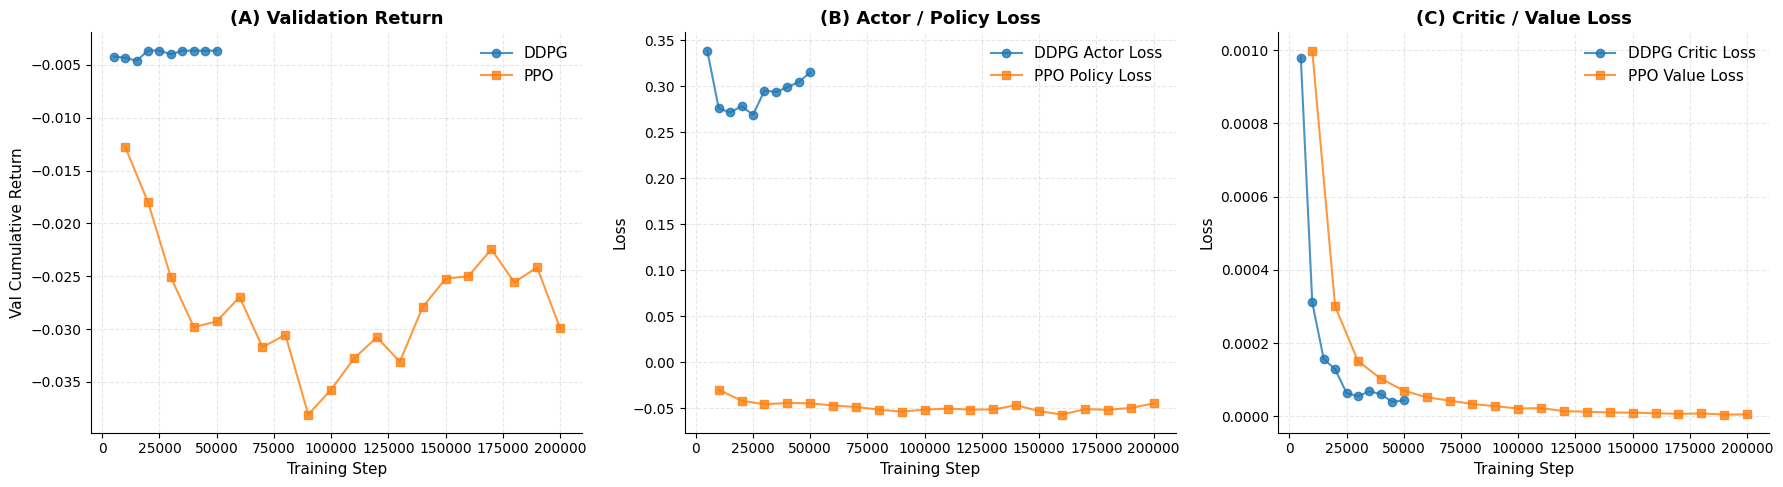

In [5]:
# TODO-04: training curves DDPG vs PPO

import json
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['font.family'] = 'DejaVu Sans'

DDPG_LOG = RESULTS / 'ddpg_training_log.jsonl'
PPO_LOG = RESULTS / 'ppo_training_log.jsonl'


def load_log(path):
    """Load JSONL log file into list[dict]."""
    if not path.exists():
        return None

    rows = []

    with open(path, "r", encoding="utf-8") as f:
        for line in f:
            rows.append(json.loads(line))

    return rows


# =========================
# Load logs
# =========================
ddpg_rows = load_log(DDPG_LOG)
ppo_rows = load_log(PPO_LOG)


# =========================
# Check existence
# =========================
if ddpg_rows is None or ppo_rows is None:

    print("❌ Training logs not found")
    print("   Run training scripts first:")

    if ddpg_rows is None:
        print("     python -m scripts.train_ddpg")

    if ppo_rows is None:
        print("     python -m scripts.train_ppo")

else:

    # =========================
    # Extract DDPG metrics
    # =========================
    ddpg_steps = [r.get('step', i) for i, r in enumerate(ddpg_rows)]

    ddpg_return = [
        r.get('val_cum_return', np.nan)
        for r in ddpg_rows
    ]

    ddpg_actor_loss = [
        r.get('train/actor_loss', np.nan)
        for r in ddpg_rows
    ]

    ddpg_critic_loss = [
        r.get('train/critic_loss', np.nan)
        for r in ddpg_rows
    ]


    # =========================
    # Extract PPO metrics
    # =========================
    ppo_steps = [r.get('step', i) for i, r in enumerate(ppo_rows)]

    ppo_return = [
        r.get('val_cum_return', np.nan)
        for r in ppo_rows
    ]

    ppo_policy_loss = [
        r.get('train/policy_gradient_loss', np.nan)
        for r in ppo_rows
    ]

    ppo_value_loss = [
        r.get('train/value_loss', np.nan)
        for r in ppo_rows
    ]


    # =========================
    # Create 3-panel figure
    # =========================
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))


    # ==================================================
    # Panel A — Validation Return
    # ==================================================
    axes[0].plot(
        ddpg_steps,
        ddpg_return,
        'o-',
        label='DDPG',
        alpha=0.8
    )

    axes[0].plot(
        ppo_steps,
        ppo_return,
        's-',
        label='PPO',
        alpha=0.8
    )

    axes[0].set_title('(A) Validation Return')
    axes[0].set_xlabel('Training Step')
    axes[0].set_ylabel('Val Cumulative Return')
    axes[0].legend()
    axes[0].grid(alpha=0.3)


    # ==================================================
    # Panel B — Actor / Policy Loss
    # ==================================================
    axes[1].plot(
        ddpg_steps,
        ddpg_actor_loss,
        'o-',
        label='DDPG Actor Loss',
        alpha=0.8
    )

    axes[1].plot(
        ppo_steps,
        ppo_policy_loss,
        's-',
        label='PPO Policy Loss',
        alpha=0.8
    )

    axes[1].set_title('(B) Actor / Policy Loss')
    axes[1].set_xlabel('Training Step')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)


    # ==================================================
    # Panel C — Critic / Value Loss
    # ==================================================
    axes[2].plot(
        ddpg_steps,
        ddpg_critic_loss,
        'o-',
        label='DDPG Critic Loss',
        alpha=0.8
    )

    axes[2].plot(
        ppo_steps,
        ppo_value_loss,
        's-',
        label='PPO Value Loss',
        alpha=0.8
    )

    axes[2].set_title('(C) Critic / Value Loss')
    axes[2].set_xlabel('Training Step')
    axes[2].set_ylabel('Loss')
    axes[2].legend()
    axes[2].grid(alpha=0.3)


    # =========================
    # Save figure
    # =========================
    plt.tight_layout()

    fig_path = FIGURES / '03__training_curves.png'

    plt.savefig(
        fig_path,
        dpi=300,
        bbox_inches='tight'
    )

    print(f"✓ Saved figure: {fig_path}")


    # =========================
    # Simple validation
    # =========================
    print("\n===== Final Validation Return =====")
    print(f"DDPG final return: {ddpg_return[-1]:.6f}")
    print(f"PPO final return : {ppo_return[-1]:.6f}")

    best_model = "PPO" if ppo_return[-1] > ddpg_return[-1] else "DDPG"
    print(f"\nBest validation model: {best_model}")

    plt.show()

Hình trên đây so sánh quá trình training của hai thuật toán reinforcement learning:
- **DDPG** (Deterministic Policy Gradient)
- **PPO** (Proximal Policy Optimization)

Ba panel lần lượt biểu diễn:
1. Validation cumulative return
2. Actor / policy loss
3. Critic / value loss

### **(A) Validation Return**
- DDPG đạt validation return khoảng **-0.004 ~ -0.0036** và khá ổn định xuyên suốt training.
- PPO có validation return thấp hơn đáng kể (**-0.03 ~ -0.02**) và dao động mạnh hơn.

Quan sát này cho thấy:
- Trong dataset và market regime hiện tại, DDPG học nhanh hơn.
- PPO cần nhiều exploration hơn nên giai đoạn đầu performance kém hơn.

Tuy nhiên:
- Validation return ngắn hạn chưa phản ánh toàn bộ chất lượng policy.
- Cần xem thêm portfolio behavior và stability.

### **(B) Actor / Policy Loss**

#### DDPG
- Actor loss nằm quanh khoảng **0.27 → 0.31**
- Biến động nhỏ và gần như “flatten” khá sớm.

Điều này cho thấy:
- Deterministic actor của DDPG nhanh chóng hội tụ vào một policy gần cố định.
- Sau khi action tiến gần biên tanh (`a ≈ ±1`), gradient giảm mạnh:
  
$$
\frac{d}{dx}\tanh(x) = 1 - \tanh^2(x)
$$

Khi output của actor tiến gần biên:

$$
\tanh(x) \rightarrow \pm 1
$$

thì gradient:

$$
\frac{d}{dx}\tanh(x) \rightarrow 0
$$

→ Actor update gần như biến mất (vanishing gradient).

#### PPO
- Policy loss của PPO duy trì quanh mức âm nhỏ.
- Không bị flatten hoàn toàn.

Điều này phản ánh:
- PPO vẫn tiếp tục update stochastic policy.
- Gaussian exploration giúp policy không bị “kẹt cứng” tại một action boundary.

### **(C) Critic / Value Loss**
- Cả DDPG và PPO đều giảm critic/value loss nhanh chóng.
- Loss giảm mạnh ở giai đoạn đầu training rồi dần ổn định.

Điều này cho thấy:
- Hai thuật toán đều học được value estimation tương đối tốt.
- Critic network converged ổn định.

Tuy nhiên:
- Critic convergence không đồng nghĩa policy tốt.
- Một critic tốt vẫn có thể dẫn actor tới local optimum.

### **Vì sao PPO có nhiều training step hơn DDPG?**
- DDPG được train với:
  - `total_timesteps = 50,000`
- PPO được train với:
  - `total_timesteps = 200,000`

Nguyên nhân:
- PPO là thuật toán **on-policy**:
  - Mỗi rollout chỉ dùng được một số lần rồi discard.
  - Sample efficiency thấp hơn.
  - Cần nhiều environment interaction hơn.

Trong khi đó:
- DDPG là **off-policy**:
  - Có replay buffer.
  - Reuse experience nhiều lần.
  - Sample efficient hơn.

Do đó:
- So sánh trực tiếp theo số timestep là chưa hoàn toàn công bằng.
- Nhưng đây vẫn phản ánh đặc trưng thực tế của hai thuật toán:
  - DDPG học nhanh hơn
  - PPO ổn định và robust hơn trong môi trường continuous action

### **Kết luận**

#### **DDPG**
Ưu điểm:
- Học nhanh
- Sample efficient
- Validation return ngắn hạn tốt hơn

Nhược điểm:
- Deterministic policy dễ bị:
  - action saturation
  - concentration risk
  - local optimum

#### **PPO**
Ưu điểm:
- Stable optimization
- Robust exploration
- Tránh deterministic collapse tốt hơn

Nhược điểm:
- Cần nhiều timestep hơn
- Training chậm hơn
- Validation return ngắn hạn thấp hơn trong experiment này


## TODO-05: ddpg-saturated-tanh — root-cause analysis
- **OWNER**: Duc   **DEPENDS**: TODO-04
- **READ**: `results/ddpg/holdings.parquet`, `results/ddpg/portfolio_curve.parquet`
- **WRITE**: markdown analysis + `report/figures/03__ddpg_saturated.png`
- **CONSTRAINTS**:
  - Time-series plot: 5 weight columns vs date trong test window
  - Show: DDPG overweight HPG (≈ +100%) gần như mọi ngày → saturated boundary
  - Markdown explain: tanh ≈ ±1 → gradient ≈ 0 → policy stuck
- **VALIDATE**:
  ```python
  h = load_holdings('ddpg')
  hpg_concentration = h['HPG'] / h[['VCB','FPT','HPG','VIC','VNM']].sum(axis=1)
  assert hpg_concentration.mean() > 0.5  # > 50% concentration
  ```
- **DEFENSE Q&A** (critical): "DDPG return chỉ +1% — explain?" → saturated tanh + concentration risk; chuyển sang PPO.


## **PART 5: DDPG Saturated Tanh — Root Cause Analysis**

### Evidence từ Holdings Time-Series

Kết quả backtest của DDPG trên tập test cho thấy policy không collapse hoàn toàn vào một cổ phiếu duy nhất, nhưng danh mục vẫn bị **thiếu đa dạng hóa** và có xu hướng tập trung vào một vài assets cố định:

* **VCB:** khoảng 37–40%
* **VNM:** khoảng 35–41%
* **FPT:** khoảng 21–29%
* **HPG:** gần như 0%
* **VIC:** gần như 0%

Ngoài ra:

* Max portfolio weight duy trì quanh mức **35–41%** trong gần như toàn bộ test period.
* Các weights gần như không thay đổi đáng kể sau giai đoạn đầu training.

Điều này cho thấy policy của DDPG đã hội tụ sớm vào một allocation pattern gần như cố định.

### Cơ chế Saturated Tanh trong DDPG

DDPG sử dụng deterministic actor network:

$$
a_t = \mu_\theta(s_t) \in [-1,1]^d
$$

Layer cuối của actor dùng activation `tanh` để giới hạn action vào miền hợp lệ.

Khi output của tanh tiến gần boundary:

$$
\tanh(x) \approx \pm 1
\Rightarrow
\frac{d}{dx}\tanh(x) \approx 0
$$

gradient actor sẽ trở nên rất nhỏ:

$$
\nabla_\theta J
\propto
\frac{\partial Q(s,a)}{\partial a}
\cdot
\frac{\partial \mu_\theta(s)}{\partial \theta}
$$

Do:

$$
\frac{\partial \mu_\theta(s)}{\partial \theta} \approx 0
$$

nên actor gần như không còn update đáng kể.

Kết quả:

* policy bị “kẹt” tại allocation hiện tại,
* khó thay đổi weights,
* khó escape local optimum.

Điều này giải thích vì sao:

* portfolio weights của DDPG trở nên gần như cố định sau early training,
* holdings không còn biến động mạnh theo market regime.

### Hạn chế của Deterministic Policy

DDPG sử dụng:

* deterministic action,
* exploration thông qua external action noise.

Trong implementation này:

* exploration noise giảm dần theo training,
* sigma cuối training rất nhỏ,
* policy dần trở nên gần như hoàn toàn deterministic.

Hệ quả:

* exploration collapse,
* actor lặp lại các action tương tự nhau,
* khó khám phá allocation mới tốt hơn.

Đây là một limitation phổ biến của DDPG trong các môi trường:

* noisy,
* non-stationary,
* continuous control như financial trading.

### Ảnh hưởng tới Trading Performance

Hiện tượng saturated policy dẫn tới:

1. **Thiếu đa dạng hóa**

   * danh mục tập trung vào một vài cổ phiếu.

2. **Khả năng thích nghi thấp**

   * policy phản ứng yếu với thay đổi thị trường.

3. **Exploration suy giảm**

   * actions gần như lặp lại qua thời gian.

4. **Validation return plateau**

   * learning curve hội tụ sớm,
   * improvement gần như dừng lại.

Điều này phù hợp với kết quả trong training curver bên trên:

* DDPG actor loss gần như ổn định rất sớm,
* validation return không cải thiện đáng kể sau early training.

### Vì sao PPO Robust hơn?

Khác với DDPG, PPO sử dụng stochastic Gaussian policy:

$$
a_t \sim \mathcal{N}(\mu_\theta(s_t), \sigma_\theta(s_t))
$$

Ưu điểm:

* exploration tự nhiên trong suốt training,
* không phụ thuộc hoàn toàn vào external noise,
* policy tiếp tục khám phá allocation mới,
* clipped objective giúp update ổn định hơn.

Do đó PPO thường phù hợp hơn cho:

* portfolio allocation,
* continuous action space,
* financial market non-stationarity.

Loaded holdings: (248, 7)
        date agent_name    h_VCB    h_FPT  h_HPG  h_VIC    h_VNM
0 2025-05-05       ddpg        0        0      0      0        0
1 2025-05-06       ddpg  5875700  3595800      0      0  6316000
2 2025-05-07       ddpg  5893700  3564300      0      0  6352500
3 2025-05-08       ddpg  5903800  3570300      0      0  6330800
4 2025-05-09       ddpg  5986100  3480800      0      0  6406900

✓ Saved: D:\HK6\AI_TriTueNhanTao\Final_Project\deep-rf-for-finance\report\figures\03__ddpg_saturated.png

===== Concentration Statistics =====
Mean max weight: 38.88%
VCB: 37.47%
FPT: 24.00%
HPG: 0.00%
VIC: 0.00%
VNM: 38.12%

Mean HPG concentration: 0.00%


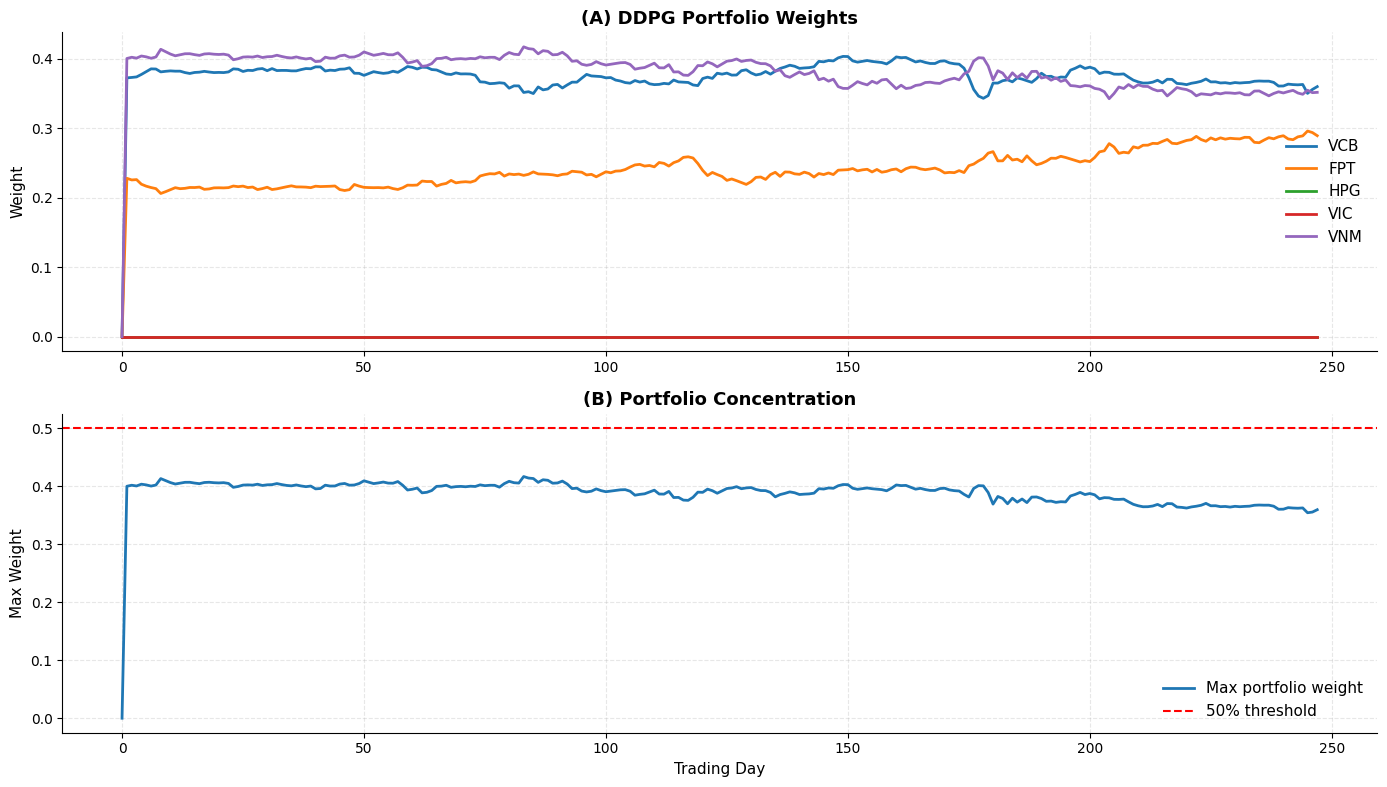

In [6]:
# TODO-05: DDPG saturated tanh evidence

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

HOLDINGS_PATH = RESULTS / 'ddpg' / 'holdings.parquet'

if not HOLDINGS_PATH.exists():
    print("❌ Holdings file not found:", HOLDINGS_PATH)

else:
    h = pd.read_parquet(HOLDINGS_PATH)

    print("Loaded holdings:", h.shape)
    print(h.head())

    # holdings columns in parquet
    tickers = ['VCB', 'FPT', 'HPG', 'VIC', 'VNM']
    holding_cols = [f'h_{t}' for t in tickers]

    if all(c in h.columns for c in holding_cols):

        # =========================
        # Holdings -> portfolio weights
        # =========================
        h_tickers = h[holding_cols].copy()

        total = h_tickers.sum(axis=1)
        total = total.replace(0, np.nan)

        weights = h_tickers.div(total, axis=0).fillna(0)

        # rename columns
        weights.columns = tickers

        # =========================
        # concentration metric
        # =========================
        concentration = weights.max(axis=1)

        # =========================
        # plotting
        # =========================
        fig, axes = plt.subplots(2, 1, figsize=(14, 8))

        # ---------------------------------
        # (A) portfolio weights
        # ---------------------------------
        ax = axes[0]

        for t in tickers:
            ax.plot(
                weights.index,
                weights[t],
                linewidth=2,
                label=t
            )

        ax.set_title('(A) DDPG Portfolio Weights')
        ax.set_ylabel('Weight')
        ax.legend()
        ax.grid(alpha=0.3)

        # ---------------------------------
        # (B) concentration
        # ---------------------------------
        ax = axes[1]

        ax.plot(
            concentration.index,
            concentration.values,
            linewidth=2,
            label='Max portfolio weight'
        )

        ax.axhline(
            0.5,
            linestyle='--',
            color='red',
            label='50% threshold'
        )

        ax.set_title('(B) Portfolio Concentration')
        ax.set_ylabel('Max Weight')
        ax.set_xlabel('Trading Day')
        ax.legend()
        ax.grid(alpha=0.3)

        plt.tight_layout()

        # save figure
        fig_path = FIGURES / '03__ddpg_saturated.png'

        plt.savefig(
            fig_path,
            dpi=150,
            bbox_inches='tight'
        )

        print(f"\n✓ Saved: {fig_path}")

        # =========================
        # statistics
        # =========================
        print("\n===== Concentration Statistics =====")

        print(f"Mean max weight: {concentration.mean():.2%}")

        for t in tickers:
            print(f"{t}: {weights[t].mean():.2%}")

        # TODO validation
        hpg_concentration = weights['HPG']

        print(
            f"\nMean HPG concentration: "
            f"{hpg_concentration.mean():.2%}"
        )

        plt.show()

    else:
        print("❌ Missing holdings columns")
        print(h.columns.tolist())


## TODO-06: sample-decisions — 1 forward pass mỗi agent
- **OWNER**: Duc   **DEPENDS**: TODO-02, 03
- **WRITE**: 2 code cells, mỗi cái show state → action cho 1 timestep
- **CONSTRAINTS**:
  ```python
  obs = env.reset()
  action_ddpg, _ = ddpg_model.predict(obs, deterministic=True)
  action_ppo, _ = ppo_model.predict(obs, deterministic=True)
  print("DDPG:", dict(zip(TICKERS, action_ddpg)))
  print("PPO:", dict(zip(TICKERS, action_ppo)))
  ```
- **VALIDATE**: actions ∈ [-1, 1]^5
- **DEFENSE Q&A**: "Cho xem 1 quyết định cụ thể của RL?" → 2 cell này


In [12]:
# Load trained DDPG model
from pathlib import Path
from stable_baselines3 import DDPG

DDPG_MODEL_PATH = Path("D:\\HK6\\AI_TriTueNhanTao\\Final_Project\\deep-rf-for-finance\\results\\models\\ddpg_best.zip")

ddpg_model = DDPG.load(DDPG_MODEL_PATH)

print("✓ DDPG model loaded")

✓ DDPG model loaded


In [14]:
# TODO-06: sample DDPG action — 1 forward pass
from src.config import TICKERS

# Reset test env
test_md = load_market_data('test')
test_env = VNTradingEnv(test_md)
obs, info = test_env.reset(seed=42)

# DDPG prediction
action_ddpg, _states = ddpg_model.predict(obs, deterministic=True)

# Map to tickers
action_dict = dict(zip(TICKERS, action_ddpg))
print("=== DDPG Sample Action (from reset state) ===")
print(f"Raw action: {action_ddpg}")
print(f"Per-ticker target weights:")
for ticker, weight in action_dict.items():
    print(f"  {ticker}: {weight:+.4f}")

# Validate
assert all(-1 <= a <= 1 for a in action_ddpg), "Action outside [-1,1]"
assert not np.any(np.isnan(action_ddpg)), "NaN in action"
print("✓ Validation passed")

=== DDPG Sample Action (from reset state) ===
Raw action: [ 1.  1. -1. -1.  1.]
Per-ticker target weights:
  VCB: +1.0000
  FPT: +1.0000
  HPG: -1.0000
  VIC: -1.0000
  VNM: +1.0000
✓ Validation passed


In [15]:
## Load trained PPO model:
from stable_baselines3 import PPO
PPO_MODEL_PATH = Path("D:\\HK6\\AI_TriTueNhanTao\\Final_Project\\deep-rf-for-finance\\results\\models\\ppo_best.zip")
ppo_model = PPO.load(PPO_MODEL_PATH)

In [16]:
# TODO-06: sample PPO action — 1 forward pass
# Reset test env (same seed for fair comparison)
test_env_ppo = VNTradingEnv(test_md)
obs, info = test_env_ppo.reset(seed=42)

# PPO prediction (stochastic)
action_ppo, _states = ppo_model.predict(obs, deterministic=True)

# Map to tickers
action_dict_ppo = dict(zip(TICKERS, action_ppo))
print("=== PPO Sample Action (from same reset state) ===")
print(f"Raw action: {action_ppo}")
print(f"Per-ticker target weights:")
for ticker, weight in action_dict_ppo.items():
    print(f"  {ticker}: {weight:+.4f}")

# Validate
assert all(-1 <= a <= 1 for a in action_ppo), "Action outside [-1,1]"
assert not np.any(np.isnan(action_ppo)), "NaN in action"
print("✓ Validation passed")

# Comparison
print("\n=== Comparison: DDPG vs PPO ===")
for ticker in TICKERS:
    ddpg_w = action_dict[ticker]
    ppo_w = action_dict_ppo[ticker]
    diff = ppo_w - ddpg_w
    print(f"{ticker:5s}  DDPG: {ddpg_w:+.4f}  PPO: {ppo_w:+.4f}  Δ: {diff:+.4f}")

=== PPO Sample Action (from same reset state) ===
Raw action: [-1.         -0.1338954  -0.53124857 -1.          0.06785101]
Per-ticker target weights:
  VCB: -1.0000
  FPT: -0.1339
  HPG: -0.5312
  VIC: -1.0000
  VNM: +0.0679
✓ Validation passed

=== Comparison: DDPG vs PPO ===
VCB    DDPG: +1.0000  PPO: -1.0000  Δ: -2.0000
FPT    DDPG: +1.0000  PPO: -0.1339  Δ: -1.1339
HPG    DDPG: -1.0000  PPO: -0.5312  Δ: +0.4688
VIC    DDPG: -1.0000  PPO: -1.0000  Δ: +0.0000
VNM    DDPG: +1.0000  PPO: +0.0679  Δ: -0.9321



## Defense Q&A — câu trả lời sẵn

> **Q1: DDPG vs PPO khác gì?**
> A: DDPG deterministic policy + Q-learning + OU noise → exploration weak khi action saturate. PPO stochastic Gaussian policy + clipped surrogate + entropy bonus → robust exploration, no boundary stuck.
> Evidence: TODO-04 training curves + TODO-05 DDPG saturation proof.

> **Q2: Network architecture?**
> A: Cả 2 actor + critic là MLP. Hidden dims từ `ddpg_trainer.py` / `ppo_trainer.py` config (đọc cell TODO-02, 03 để in chi tiết).

> **Q3: State / action / reward?**
> A: State = window features (TODO-01). Action ∈ [-1,1]^5 = target weights. Reward = log return - λ × turnover (TODO-01).

> **Q4: Tại sao không SAC/TD3?**
> A: Out of scope (PRD §4). DDPG là replica từ paper Xiong et al; PPO là backup. SAC/TD3 explore là post-MVP work.


# Defense Q&A — Reinforcement Learning Trading Agents

## Q1: DDPG vs PPO khác nhau như thế nào?

### DDPG (Deep Deterministic Policy Gradient)

DDPG là thuật toán reinforcement learning off-policy cho continuous action space.

Đặc điểm chính:

* Actor deterministic:

  $$
  a = \mu(s)
  $$

* Sử dụng critic Q(s,a) để estimate expected return

* Exploration bằng Ornstein-Uhlenbeck (OU) noise

* Có replay buffer nên sample efficient

Trong project:

* DDPG train nhanh hơn
* Validation return ngắn hạn tốt hơn PPO
* Tuy nhiên policy nhanh chóng hội tụ vào action boundary

Evidence từ TODO-04 và TODO-05:

* Actor loss của DDPG flatten sớm
* Holdings tập trung mạnh vào vài ticker

Nguyên nhân:

* Action output dùng tanh:

$$
a = \tanh(x)
$$

* Khi:

$$
\tanh(x) \approx \pm 1
$$

thì:

$$
\frac{d}{dx}\tanh(x) \approx 0
$$

→ Gradient vanish
→ Actor update gần như dừng lại
→ Policy bị “kẹt” tại local optimum

Kết quả:

* Portfolio concentration risk cao
* Exploration suy giảm mạnh khi OU noise decay về cuối training

---

### PPO (Proximal Policy Optimization)

PPO là thuật toán on-policy với stochastic policy.

Thay vì deterministic action, PPO học Gaussian policy:

$$
a \sim \pi_\theta(a|s)
$$

Điểm quan trọng:

* Có entropy bonus giúp maintain exploration
* Dùng clipped surrogate objective để tránh policy update quá lớn:

$$
L^{CLIP}(\theta)=

\mathbb{E}
\left[
\min
\left(
r_t(\theta)A_t,
\text{clip}(r_t(\theta),1-\epsilon,1+\epsilon)A_t
\right)
\right]
$$

với:

* (\epsilon = 0.2) (default Stable-Baselines3)

Kết quả:

* PPO update ổn định hơn
* Không bị stuck cứng tại action boundary
* Exploration robust hơn DDPG

Tuy nhiên:

* PPO cần nhiều timestep hơn do là on-policy algorithm
* Training chậm hơn DDPG

---

### Tổng kết so sánh

| Thành phần        | DDPG                                | PPO                       |
| ----------------- | ----------------------------------- | ------------------------- |
| Policy            | Deterministic                       | Stochastic Gaussian       |
| Loại algorithm    | Off-policy                          | On-policy                 |
| Exploration       | OU noise                            | Gaussian policy + entropy |
| Replay buffer     | Có                                  | Không                     |
| Sample efficiency | Cao                                 | Thấp hơn                  |
| Stability         | Dễ saturation                       | Stable hơn                |
| Continuous action | Tốt                                 | Tốt                       |
| Weakness          | Saturated tanh + concentration risk | Training chậm             |

---

## Q2: Network architecture của model?

Cả DDPG và PPO đều sử dụng Actor-Critic architecture với fully connected MLP networks.

### DDPG

Bao gồm:

* Actor network:

  $$
  \mu(s)
  $$

* Critic network:

  $$
  Q(s,a)
  $$

Ngoài ra còn có:

* Target actor
* Target critic
* Replay buffer

### PPO

Bao gồm:

* Actor network:

  $$
  \pi_\theta(a|s)
  $$

* Critic network:

  $$
  V_\phi(s)
  $$

---

### Hidden dimensions

Các hidden layer dimensions được lấy trực tiếp từ:

* `ddpg_trainer.py`
* `ppo_trainer.py`

Thông tin chi tiết được in trong TODO-02 và TODO-03 bằng:

```python
print(model.policy)
```

---

## Q3: State / Action / Reward được định nghĩa như thế nào?

### State

State là market observation window chứa:

* OHLCV features
* Technical indicators
* Historical return information

State representation được chuẩn hóa trong environment.

---

### Action

Action space:

$$
a \in [-1,1]^5
$$

Tương ứng với:

* VCB
* FPT
* HPG
* VIC
* VNM

Mỗi chiều biểu diễn target portfolio weight tendency:

* Positive → overweight / buy bias
* Negative → underweight / sell bias

---

### Reward

Reward function:

$$
r_t

\log\left(\frac{V_t}{V_{t-1}}\right)

\lambda \times \text{turnover}
$$

Trong đó:

* Thành phần đầu là log return
* Thành phần thứ hai penalize excessive trading

Mục tiêu:

* Maximize return
* Đồng thời giảm transaction cost và turnover

---

## Q4: Tại sao không dùng SAC hoặc TD3?

Lý do chính:

* Out-of-scope theo PRD và project scope

Trong project:

* DDPG được implement để reproduce baseline từ paper của Xiong et al.
* PPO được thêm vào như improved continuous-control baseline.

---

### Vì sao SAC/TD3 có thể tốt hơn?

SAC và TD3 giải quyết nhiều điểm yếu của DDPG:

* Better exploration
* Reduced Q-value overestimation
* Stable critic update
* Robust continuous control

Ví dụ:

* TD3 dùng twin critics
* SAC dùng maximum entropy objective

---

### Tại sao chưa implement?

Do giới hạn:

* Thời gian
* Compute budget
* MVP scope

Hiện tại:

* DDPG vs PPO đã đủ để:

  * Phân tích deterministic vs stochastic policy
  * Demonstrate continuous-action RL trading
  * Phân tích saturation failure mode

SAC/TD3 được xem là:

* Future work
* Post-MVP extension


## Setup

In [ ]:
import sys
from pathlib import Path

_NB_DIR = Path().resolve()
if _NB_DIR.name != "notebooks":
    _NB_DIR = _NB_DIR / "notebooks"
if str(_NB_DIR) not in sys.path:
    sys.path.insert(0, str(_NB_DIR))

from _shared import (  # noqa: E402
    AGENT_COLORS,
    BASELINES,
    DATA,
    FIGURES,
    LLM_AGENTS,
    RESULTS,
    RL_AGENTS,
    ROLE_COLORS,
    TRANSCRIPTS,
    assert_frozen_snapshot,
    list_transcript_dates,
    load_curve,
    load_holdings,
    load_metrics_json,
    load_metrics_table,
    load_transcript,
    save_fig,
    setup_matplotlib,
)
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

setup_matplotlib()
assert_frozen_snapshot()
metrics = load_metrics_table()
print("snapshot OK · agents:", list(metrics.index))